# Placement POC — sensor sets with quantified dependence, per district partition

The upstream step attributed districts several ways. This notebook takes each partition,
sweeps *which district drifts*, measures what every gauge is reading, and emits the
`(district attribution, sensor placement)` tuples the federated step consumes.

Order: one case end to end with its sanity checks → the full sweep → summary and the
interactive views → the selected sets checked against demand and against the map.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 250)

HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
for p in (HERE, ROOT / "src", ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import bundles as bd
import district_sweep as ds
import placement as pl
import placement_figures as F
import placement_browsers as B
import signal_probe as sp
import mixture_probe as mp

INPUT = next(p for p in (HERE.parent / "input", HERE / "input", ROOT / "input")
             if p.exists())
STORE  = ROOT / "data" / "09_experiments" / "placement"
WORLDS = STORE / "worlds"
STORE.mkdir(parents=True, exist_ok=True)
print(ROOT, "|", INPUT)

c:\Users\arthu\USPy\10_Mestrado\fedWater | c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\0_prospection\input


## 1. Partitions → bundles

Each partition becomes its own self-describing network bundle under `data/01_raw/`, named
with a content hash of the partition itself. That is what keeps the world cache honest:
`network` is already part of `WorldCfg.identity()`, so two partitions address two worlds
and editing a partition orphans its stale worlds instead of silently reusing them.

`coverage` below is the share of a district reachable from its seed without leaving the
district. Below 1.0 the diffusion front cannot convert the whole district and the settled
state genuinely depends on the seed — read those cells as partial conversions.
`eccentricity` is the hop count the front must travel, and it is what sizes the horizon.

In [2]:
anchor_scale = 0.50
BUNDLES = bd.prepare(ROOT, INPUT, methods=bd.PIPELINE_METHODS, base_network="ky72", anchor_scale = anchor_scale)
display(pd.DataFrame([b.summary() for b in BUNDLES]))
display(pd.concat([b.seeds.assign(config=b.config_id) for b in BUNDLES],
                  ignore_index=True))

materialising bundles from c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\0_prospection\input
  fast_greedy__2ab65bc6        -> ky72__fast_greedy__2ab65bc6  k=4 sizes=170/158/87/66  min coverage 0.99  max ecc 16
  girvan_newman__6f359aad      -> ky72__girvan_newman__6f359aad  k=4 sizes=237/105/99/40  min coverage 1.00  max ecc 19
  spectral__29fddafe           -> ky72__spectral__29fddafe  k=4 sizes=215/206/30/30  min coverage 1.00  max ecc 26


,config_id,method,network,k,sizes,min_coverage,max_eccentricity,districts_without_storage
0,fast_greedy__2ab65bc6,fast_greedy,ky72__fast_greedy__2ab65bc6,4,170/158/87/66,0.987,16,1
1,girvan_newman__6f359aad,girvan_newman,ky72__girvan_newman__6f359aad,4,237/105/99/40,1.000,19,1
2,spectral__29fddafe,spectral,ky72__spectral__29fddafe,4,215/206/30/30,1.000,26,1


,district,seed_node,n_nodes,components,coverage,eccentricity,seed_base_demand,config
0,District_A,J-165,170,1,1.0000,16,2.65,fast_greedy__2ab65bc6
1,District_B,J-240,158,2,0.9873,13,4.56,fast_greedy__2ab65bc6
2,District_C,J-64,87,1,1.0000,12,1.32,fast_greedy__2ab65bc6
3,District_D,J-146,66,1,1.0000,10,1.85,fast_greedy__2ab65bc6
4,District_A,J-332,237,1,1.0000,19,1.51,girvan_newman__6f359aad
5,District_B,J-330,105,1,1.0000,10,2.73,girvan_newman__6f359aad
6,District_C,J-237,99,1,1.0000,14,1.47,girvan_newman__6f359aad
7,District_D,J-385,40,1,1.0000,7,5.35,girvan_newman__6f359aad
8,District_A,J-177,215,1,1.0000,26,14.80,spectral__29fddafe
9,District_B,J-499,206,1,1.0000,20,1.70,spectral__29fddafe


### Horizon

The front width is derived from the largest district rather than fixed. With one constant,
a partition whose districts are uneven converts the small ones in two months and the large
one in thirty — and at a fixed horizon the large cell then has no settled tail at all and
`settled_window` raises. This is a *width* change to the diffusion front, which the drift
engine already parameterises; the mechanism is untouched.

`beta` is a hyperparameter now, not an axis. The consequence, stated where it will be
read: with one operating point there is no linearity check, so every dependence number
below is an operating-point statement and cannot be quoted at another beta.

In [3]:
BETA = 0.35
PLAN = ds.plan(BUNDLES, beta=BETA, anchor_scale=anchor_scale, warmup_months = 8,)
CFG  = PLAN.cfg
print(f"\ngrid: {len(BUNDLES)} configurations x {len(BUNDLES[0].districts)} drift "
      f"districts = {len(BUNDLES) * len(BUNDLES[0].districts)} worlds")

horizon plan: n_months=44 x 14d | warmup 8 | front 10 nodes/month -> converts 237 nodes in ~26 months (eccentricity floor 26)

grid: 3 configurations x 4 drift districts = 12 worlds


## 2. One case, end to end

Everything that can go wrong quietly goes wrong here first. Pick one partition and solve
its K worlds before committing to the grid.

In [4]:
B0 = BUNDLES[2]
R0 = ds.run_config(B0, CFG, ROOT, WORLDS, null_factor=ds.NULL_FACTOR,
                   core_purity=ds.CORE_PURITY)
display(R0.cells[["drift_district", "status", "source", "d_demand_%",
                  "shape_shift", "gap_flow", "resp_flow_top", "seconds"]])
print(R0.status, "|", R0.error or "-")


=== spectral__29fddafe (spectral) -- 4 worlds ===


  [1/4] ky72__spectral__29fddafe/District_A/beta=0.35  cache  dDemand  +117.2%  shift 0.72  flow gap 0.82  resp 1.00  3s  | eta 0 min
  [2/4] ky72__spectral__29fddafe/District_B/beta=0.35  cache  dDemand  +117.5%  shift 0.72  flow gap 0.91  resp 0.79  2s  | eta 0 min
  [3/4] ky72__spectral__29fddafe/District_C/beta=0.35  cache  dDemand  +116.8%  shift 0.73  flow gap 0.60  resp 1.00  2s  | eta 0 min
  [4/4] ky72__spectral__29fddafe/District_D/beta=0.35  cache  dDemand  +117.7%  shift 0.73  flow gap 1.03  resp 1.00  2s  | eta 0 min

4/4 cells ok in 0.1 min -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\placement\worlds\spectral__29fddafe
  District_A: settled from month 32
  District_B: settled from month 31
  District_C: settled from month 15
  District_D: settled from month 14
  done in 0.3 min | {'core': 270, 'foreign': 60, 'transition': 266, 'unusable': 471}
  !! pressure channel DEGENERATE: pairwise tv 0.000, 1 distinct rows in 3 gauges -- dropped from the placement

,drift_district,status,source,d_demand_%,shape_shift,gap_flow,resp_flow_top,seconds
0,District_A,ok,cache,117.227,0.723,0.820170,0.999498,2.9
1,District_B,ok,cache,117.450,0.721,0.910638,0.792624,1.8
2,District_C,ok,cache,116.836,0.730,0.601712,0.999757,1.8
3,District_D,ok,cache,117.677,0.727,1.033882,0.999999,2.0


ok | -


### 2a. Did the drift land where it was aimed?

The one assumption this refactor could not verify from the code alone. Each bundle writes
its own `drift_seed_nodes`, but `build_drift_schedule` reads the profile only as a
*fallback* behind `scenario.drift.seed_node`, and the precedence lives upstream. If the
seed resolved to a node outside its target district, the schedule would seed the drift in
the wrong place — silently.

`in_target` must be 1.00 everywhere. `coverage` is the share of the target district the
front actually converted; below 1.0 the mixture is measuring a partial conversion.

In [5]:
rows = []
for d, P in R0.probes.items():
    sch = P.schedule
    tgt = set(P.districts[d])
    seeded = set(sch["node"].astype(str))
    first = sch.loc[sch["drift_month"] == sch["drift_month"].min(), "node"].astype(str)
    rows.append({"drift_district": d, "n_scheduled": len(sch),
                 "in_target": round(len(seeded & tgt) / max(len(seeded), 1), 3),
                 "coverage": round(len(seeded & tgt) / len(tgt), 3),
                 "seed_node": list(first)[0],
                 "seed_in_target": list(first)[0] in tgt,
                 "first_month": int(sch["drift_month"].min()),
                 "last_month": int(sch["drift_month"].max())})
SEEDCHK = pd.DataFrame(rows)
display(SEEDCHK)
assert (SEEDCHK["in_target"] == 1.0).all(), "drift scheduled outside its target district"
assert SEEDCHK["seed_in_target"].all(), "seed node is not in the district it seeds"
print("seed resolution ok")

,drift_district,n_scheduled,in_target,coverage,seed_node,seed_in_target,first_month,last_month
0,District_A,215,1.0,1.0,J-177,True,8,39
1,District_B,206,1.0,1.0,J-499,True,8,35
2,District_C,30,1.0,1.0,J-282,True,8,15
3,District_D,30,1.0,1.0,J-270,True,8,14


seed resolution ok


### 2b. Settling

`final` cannot start at `last_switch + ramp`: the profile is still moving there. The
threshold is self-calibrating — the reproducibility ceiling is measured from the reference
months, and "settled" means within a slack of it, where the slack is at least twice the
spread of those months. A fixed 0.99 would report "never settled" on any world noisy
enough to be realistic.

,drift_district,n_months,last_switch,settle_month,settled_from,settled_months,ok,need_n_months
0,District_A,44,39,31,32,12,True,35
1,District_B,44,35,30,31,13,True,34
2,District_C,44,15,14,15,29,True,18
3,District_D,44,14,13,14,30,True,17


,district,drifted,settle_month,ceiling,threshold,r_min,r_at_first_final,drift_district
0,District_A,True,31,1.0000,0.9900,0.2748,0.9998,District_A
5,District_B,True,30,0.9999,0.9899,0.2768,0.9998,District_B
10,District_C,True,14,0.9992,0.9892,0.2631,0.9990,District_C
15,District_D,True,13,0.9997,0.9897,0.2653,0.9996,District_D


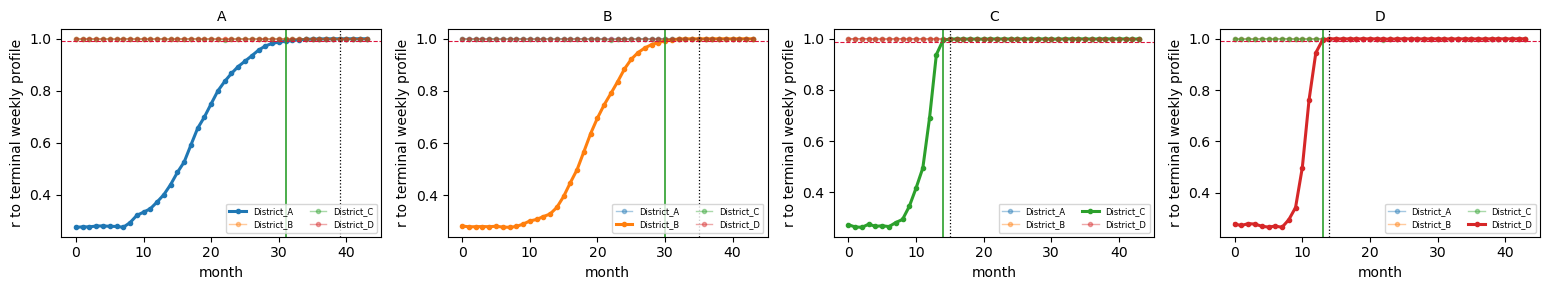

In [6]:
display(R0.horizon)
display(R0.settle[R0.settle["drifted"]])

fig, axes = plt.subplots(1, len(R0.probes), figsize=(3.9 * len(R0.probes), 3.0),
                         squeeze=False)
F.settle_panel(axes[0], R0.probes)
plt.tight_layout(); plt.show()

### 2c. Is the mixture informative, or is the threshold doing the work?

`n_live<=1_%` first. If nearly every gauge cleared the gate for exactly one district the
shares are one-hot by construction and say nothing about coupling — a statement about the
threshold, not the network. The sensitivity table is the check: a tier count that moves a
lot between `null_factor` 1 and 3 is a threshold result. `purity_histogram` shows where
the mass actually sits; mass in the middle is the population that can support a quantified
dependence statement at all.

In [7]:
display(mp.mixture_diagnostics(R0.base))
display(mp.tier_sensitivity(R0.base, factors=ds.NULL_FACTORS))
display(mp.purity_histogram(R0.base))
display(R0.stability.describe().round(3))

,kind,n,unusable_%,n_live<=1_%,n_live_mean,purity_median,snr_median,neg_mass_%
0,flow,604,1.821,30.629,3.002,0.744,9.901,68.212
1,pressure,463,99.352,0.000,3.819,1.000,6.786,100.000


,null_factor,core_purity,kind,core,transition,foreign,unusable,n_live_mean
0,1.0,0.85,flow,270,267,60,7,3.35
1,1.0,0.85,pressure,3,0,38,422,4.00
2,1.5,0.85,flow,267,266,60,11,3.00
3,1.5,0.85,pressure,3,0,0,460,3.82
4,3.0,0.85,flow,274,251,59,20,2.75
5,3.0,0.85,pressure,3,0,0,460,3.05


,kind,bin,n,share
0,flow,"[0.0, 0.15)",60,0.101
1,flow,"[0.15, 0.3)",40,0.067
2,flow,"[0.3, 0.5)",117,0.197
3,flow,"[0.5, 0.7)",66,0.111
4,flow,"[0.7, 0.85)",43,0.073
5,flow,"[0.85, 0.95)",25,0.042
6,flow,"[0.95, 1.001)",242,0.408
7,pressure,"[0.0, 0.15)",0,0.000
8,pressure,"[0.15, 0.3)",0,0.000
9,pressure,"[0.3, 0.5)",0,0.000


,purity_min,purity_max,purity_swing
count,1067.000,1067.000,1067.000
mean,0.366,0.381,0.015
std,0.417,0.425,0.104
min,0.000,0.000,0.000
25%,0.000,0.000,0.000
50%,0.118,0.173,0.000
75%,0.835,0.931,0.000
max,1.000,1.000,1.000


### 2d. Fundamentals — what each quantity measures, and how they connect

**Excitation.** Each world converts exactly one district's land use. On the z-scored weekly
profile, `Δz_d(k)` is that district's change of *temporal signature* — a pure level change
scores zero, which is the point: level is what per-client MinMax scaling destroys, shape is
what survives it.

**Elasticity `E[s,k]`.** Project a gauge's own `Δz_s` onto the unit direction of
`Δz_d(k)`, soft-threshold against the projection noise `ν` measured on the *same*
direction, divide by the excitation size. So `E` is "how much of district k's signature
reached this gauge, per unit of k's change".

**Mixture.** Normalise a gauge's positive responses across k to a simplex. `purity` is its
own district's share. A gauge at 0.75/0.25 is literally reading three parts its own client
and one part the neighbour — the tiers (`core` / `transition` / `foreign` / `unusable`) are
just regions of that axis.

**Dependence `D[j,k]` and `R = D/diag(D)`.** Average `|E|` over *every* gauge homed in j —
not the best few, because selecting the purest gauges and then measuring purity drives the
off-diagonal to zero by construction. `R[j,k]` reads "j's meters respond R as strongly to
k's drift as to j's own". Diagonal 1, asymmetric on purpose, and `R > 1` is meaningful.

**Response matrices.** The transpose, restricted to a tier. `core` should be near-diagonal
by definition; if `transition` is *not* markedly more coupled, the tiering separates
nothing and the target arm is not a target.

**The thesis link, and the limit of the claim.** Each district's demand is generated
independently, so nothing here says client j's *demand* depends on client k's. It says
client j's *observations* are contaminated by client k's demand — which is exactly the
confound federated training faces, now measured from real conversions at the real
operating point rather than inferred from the observables FL will also train on. Influence
is not causality: this licenses a statement about whose demand reaches whose meters, and
nothing about direction in the time-series sense.

In [8]:
display(R0.dependence["flow"]["R"].round(3))
display(mp.dependence_summary(R0.dependence["flow"]["R"]))
display(mp.asymmetry(R0.dependence["flow"]["R"]))
display(R0.checks)

,District_A,District_B,District_C,District_D
District_A,1.000,0.185,0.094,0.062
District_B,0.286,1.000,0.119,0.073
District_C,0.284,0.282,1.000,0.042
District_D,0.001,0.001,0.001,1.000


,in_mean,in_max,out_mean,out_max,net,strongest_source
District_A,0.114,0.185,0.190,0.286,0.076,District_B
District_B,0.159,0.286,0.156,0.282,-0.003,District_A
District_C,0.203,0.284,0.071,0.119,-0.132,District_A
District_D,0.001,0.001,0.059,0.073,0.058,District_C


,District_A,District_B,District_C,District_D
District_A,0.000,-0.101,-0.190,0.062
District_B,0.101,0.000,-0.163,0.072
District_C,0.190,0.163,0.000,0.041
District_D,-0.062,-0.072,-0.041,0.000


,kind,space,n_gauges,noise_pass_rate,shrink_effect_r,diag_dominance,median_nu_over_proj
0,flow,shape,604,0.1432,0.9934,0.7599,0.0642
1,flow,native,604,0.1531,0.9367,0.6606,0.0968
2,pressure,shape,463,0.0470,0.9987,0.0518,0.1689
3,pressure,native,463,0.2192,0.9974,0.0648,0.2484


### 2e. Verification — contiguity, and the estimator's own diagnostics

,district,kind,n_core,components,largest_share
0,District_A,flow,127,23,0.246835
1,District_B,flow,93,7,0.759259
2,District_C,flow,16,2,0.684211
3,District_D,flow,31,1,1.000000
4,District_A,pressure,0,0,NaN
5,District_B,pressure,0,0,NaN
6,District_C,pressure,0,0,NaN
7,District_D,pressure,3,2,0.666667


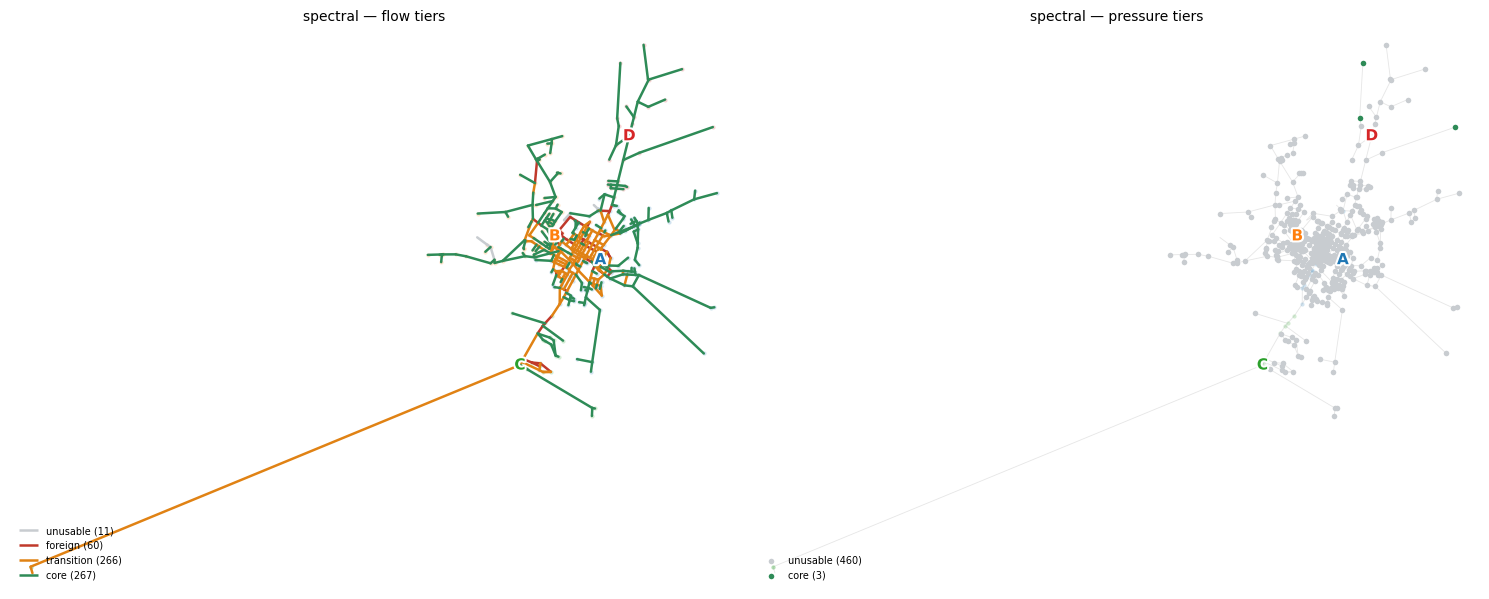

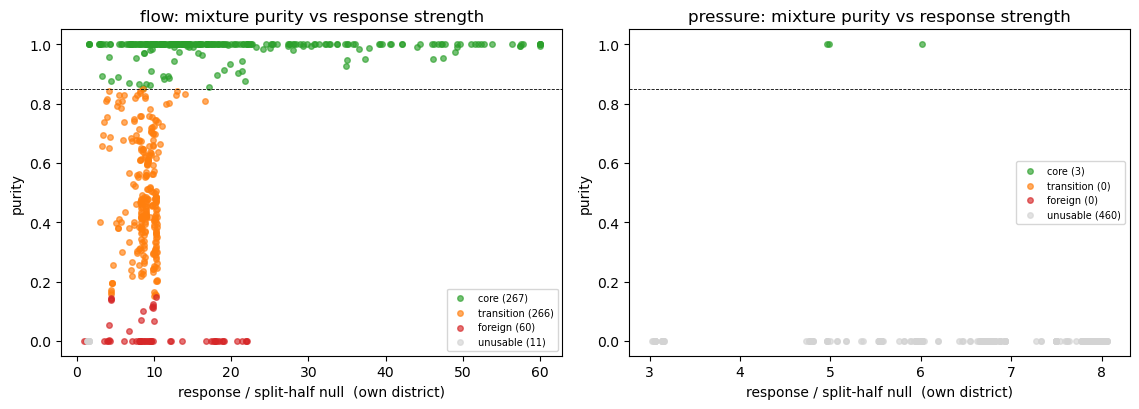

In [9]:
display(R0.connectivity)

TOPO = bd.topology(ROOT / "data" / "01_raw" / B0.network / "network.inp")
TAB0 = pl.classification(R0)
fig, ax = plt.subplots(1, 2, figsize=(15, 6.4))
F.tier_network(ax[0], TOPO, TAB0, R0.districts, "flow", title=f"{R0.method} — flow tiers")
F.tier_network(ax[1], TOPO, TAB0, R0.districts, "pressure",
               title=f"{R0.method} — pressure tiers")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
for a, k in zip(ax, ("flow", "pressure")):
    mp.plot_purity({"mixture": R0.mixture, "districts": R0.names}, k, ax=a)
plt.tight_layout(); plt.show()

### 2f. Does each channel carry a placement at all?

A mixture is only informative if it VARIES BETWEEN GAUGES. On KY7 every
pressure gauge reports the same simplex row — the interquartile range of the
largest weight spans 0.005 across 463 gauges, because pressure there is the
tank-and-pump state and has one degree of freedom. Each gauge looks like a
clean 49/44 two-district blend and sails through any per-gauge gate; 456 of
them passed the top-two test, containing 28 distinct readings.

No gauge-level test catches that. A uniform-smear detector (`hhi ≈ 1/K` with
all districts live) flags 97% of KY7 fast_greedy pressure and **0.0%** of KY7
girvan_newman pressure — the more degenerate channel by every diversity
measure — while falsely flagging 19–28% of D-Town pressure, which is genuinely
diverse. Degeneracy belongs to the channel, not to any gauge's row.

`mean_pairwise_tv` measures it across gauges and separates cleanly: 0.048–0.115
on KY7 pressure against 0.655–0.775 everywhere else. A `degenerate` channel is
dropped from the arms and still reported, because "this channel has one degree
of freedom" is a finding about the network.

,kind,n_live,distinct_rows,distinct_share,mean_pairwise_tv,eff_rank,verdict
0,flow,593,307,0.5177,0.5565,2.691,ok
1,pressure,3,1,0.3333,0.0000,0.000,degenerate


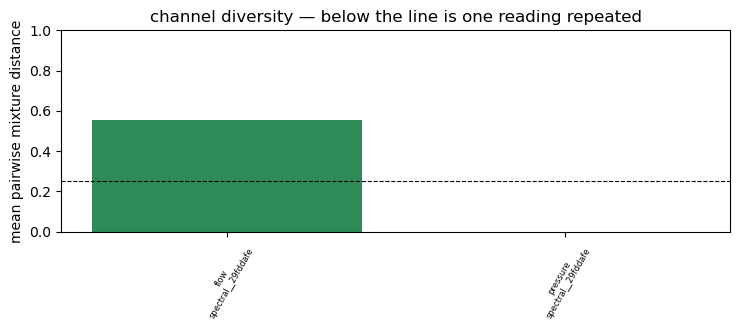

In [10]:
display(R0.channels)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
F.channel_bars(ax, R0.channels.assign(config_id=R0.config_id),
               min_tv=pl.CHANNEL_MIN_TV)
plt.tight_layout(); plt.show()

## 3. The sweep

Every partition, cached and resumable. A configuration that fails is recorded and the grid
continues — an infeasible partition is a result about that partition. Note that a
configuration needs *all* K worlds: the mixture stacks one per district, so a missing world
is a missing column, not a smaller sample.

In [11]:
RESULTS = ds.run(BUNDLES, CFG, ROOT, STORE, worlds_root=WORLDS)
SUMM = ds.summarise(RESULTS)
display(SUMM)


=== fast_greedy__2ab65bc6 (fast_greedy) -- 4 worlds ===
  [1/4] ky72__fast_greedy__2ab65bc6/District_A/beta=0.35  cache  dDemand  +117.3%  shift 0.72  flow gap 0.83  resp 1.00  5s  | eta 0 min
  [2/4] ky72__fast_greedy__2ab65bc6/District_B/beta=0.35  cache  dDemand  +116.2%  shift 0.71  flow gap 0.92  resp 0.79  2s  | eta 0 min
  [3/4] ky72__fast_greedy__2ab65bc6/District_C/beta=0.35  cache  dDemand  +117.8%  shift 0.72  flow gap 0.67  resp 1.00  2s  | eta 0 min
  [4/4] ky72__fast_greedy__2ab65bc6/District_D/beta=0.35  cache  dDemand  +117.6%  shift 0.72  flow gap 1.02  resp 1.00  2s  | eta 0 min

4/4 cells ok in 0.2 min -> c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\placement\worlds\fast_greedy__2ab65bc6
  District_A: settled from month 27
  District_B: settled from month 25
  District_C: settled from month 21
  District_D: settled from month 18
  done in 0.3 min | {'core': 273, 'foreign': 115, 'transition': 213, 'unusable': 466}
  !! pressure channel DEGENERATE: pai

,config_id,method,status,seconds,cells_ok,cells,flow_offdiag,flow_offdiag_max,flow_offdiag_gt1,pressure_offdiag,pressure_offdiag_max,pressure_offdiag_gt1,flow_channel,flow_tv,pressure_channel,pressure_tv,n_core,n_transition,n_foreign,n_unusable,min_coverage,error
0,fast_greedy__2ab65bc6,fast_greedy,ok,19.0,4,4,0.1418,0.4119,0,1.7672,4.4353,9,ok,0.6506,degenerate,0.0,273,213,115,466,0.987,
1,girvan_newman__6f359aad,girvan_newman,ok,30.9,4,4,0.1719,0.6052,0,2.7435,9.1261,7,ok,0.5782,degenerate,0.0,455,55,82,475,1.000,
2,spectral__29fddafe,spectral,ok,17.4,4,4,0.1192,0.2855,0,1.5829,3.8080,6,ok,0.5565,degenerate,0.0,270,266,60,471,1.000,


## 4. Summary across partitions

Per-gauge rows cannot be pooled across configurations — `home` is partition-dependent, so
the same element is a different observation under a different cut. The element *is* shared,
though, so keying on it answers the one cross-configuration question that is well posed:
which elements are readable whatever the cut.

In [12]:
EL = ds.elements(RESULTS)
display(EL.groupby(["method", "kind", "tier"]).size().unstack(fill_value=0))

robust = (EL[EL["tier"].isin(["core", "transition"])]
          .groupby(["element", "kind"])
          .agg(n_configs=("config_id", "nunique"),
               purity_mean=("purity", "mean"), purity_sd=("purity", "std"),
               swing=("purity_swing", "mean")).reset_index())
robust = robust[robust["n_configs"] == EL["config_id"].nunique()]
display(robust.sort_values("purity_sd").head(20).round(3))
print(f"{len(robust)} elements readable under every partition")

tier                    core  foreign  transition  unusable
method        kind                                         
fast_greedy   flow       266      115         213        10
              pressure     7        0           0       456
girvan_newman flow       437       82          55        30
              pressure    18        0           0       445
spectral      flow       267       60         266        11
              pressure     3        0           0       460

,element,kind,n_configs,purity_mean,purity_sd,swing
1,J-149,pressure,3,1.0,0.0,0.027
439,P-51,flow,3,1.0,0.0,0.004
437,P-508,flow,3,1.0,0.0,0.000
431,P-501,flow,3,1.0,0.0,0.000
429,P-50,flow,3,1.0,0.0,0.000
428,P-5,flow,3,1.0,0.0,0.000
427,P-499,flow,3,1.0,0.0,0.001
185,P-264,flow,3,1.0,0.0,0.000
424,P-496,flow,3,1.0,0.0,0.010
422,P-494,flow,3,1.0,0.0,0.000


403 elements readable under every partition


## 5. Interactive views

**Sweep browser** — the response/leak matrix beside the resemblance metric drawn on the
network. The slider keeps the top N gauges per district; the metric drives colour and size
together, so a district whose best gauges are faint and thin is one no placement recovers.

In [13]:
_ = B.sweep_browser(RESULTS, TOPO)

**Mixture browser** — one configuration: tiers on the network with district identity,
the per-district simplex, and the two matrices. `dependence R[j,k]` uses every gauge and no
threshold; `response` is the tier-restricted transpose.

In [ ]:
_ = B.mixture_browser(RESULTS[BUNDLES[2].config_id], TOPO)

**Lab browser** — one world: weekly shapes, the selection map, and the shape-distance
clustering. The selection map's upper right is where a prototype comes from; a gauge with
high resemblance and response ≈ 0 is dominated by transit flow.

In [15]:
P0 = R0.probes[sorted(R0.probes)[0]]
SC0 = R0.scores[R0.scores["sim_hash"] == P0.label.split(":")[-1]]
if not len(SC0):
    SC0 = R0.scores[R0.scores["drift_district"] == sorted(R0.probes)[0]]
_ = B.lab_browser(P0, SC0)

## 6. Sensor sets

Four arms per configuration, each a complete `sensors:` block of at most 5
**distinct readings** per district per kind.

    control_high   tier core, w2 ≤ 0.15       reads almost only its own district
    control_low    tier foreign, top2 ≥ 0.90  responds strongly, to the WRONG district
    target         top2 ≥ 0.90, w2 ≥ 0.20,    a quantified blend of two named districts
                   n_mass ≥ 2, swing ≤ 0.20
    unusable       flat for every drift       report only, never a pipeline arm

The target is defined on **top-two concentration**, not on a purity band. A
band anchored on the home share does not transfer: on D-Town the dependence
sits in `transition`, on KY7 it sits in `foreign`, where a link inside district
j is dominated by k's transit. `w1 + w2 ≥ 0.90` with `w2 ≥ 0.20` admits a 60/40
and a 20/80 alike and rejects a five-way smear, whichever district is home. The
shipped D-Town girvan_newman set spans both tiers for exactly that reason.

Stability is tested with `purity_swing`, not with tier-label constancy. A gauge
near the core/transition boundary flips its label while its weights barely
move; gating on the label cost three of five districts their target sensor.

**Dedup runs in two different spaces.** For `target` the mixture IS the
criterion, so distance is total variation between simplex rows — adjacent links
in series carry identical flow and land at distance ≈ 0. For the controls a
one-hot row is the DEFINITION of the arm, so mixture distance would collapse
each district to one member; those dedup on the response profile instead.

Short sets ship ragged. `coverage.csv` separates the two reasons: `n_eligible`
0 means no gauge met the criteria, while `n_eligible` 15 with `n_selected` 2
means plenty of gauges and two distinct readings — `redundancy` names that case.

In [16]:
for cid, r in RESULTS.items():
    if r.status != "ok":
        print(f"{cid}: skipped ({r.status}) {r.error}"); continue
    print(f"# ---- {cid} ----")
    pl.emit(r, STORE, arms=pl.PIPELINE_ARMS, n_max=5)

COV = pd.concat([pd.read_csv(STORE / cid / "placements" / "coverage.csv")
                 for cid, r in RESULTS.items() if r.status == "ok"],
                ignore_index=True)
display(COV.groupby(["config_id", "arm", "kind"])
        .agg(gauges=("n_selected", "sum"), short=("complete", lambda x: (~x).sum()),
             empty=("empty", "sum")).reset_index())

# ---- fast_greedy__2ab65bc6 ----
  channel flow     ok         tv 0.651 | 256/594 distinct (43.1%) | eff rank 2.87
  channel pressure degenerate tv 0.000 | 1/7 distinct (14.3%) | eff rank 0.00
  control_high    20 gauges | 4/8 sets short | 4 empty | redundancy 13.3x
  control_low     15 gauges | 5/8 sets short | 5 empty | redundancy 7.3x
  target          14 gauges | 6/8 sets short | 5 empty | redundancy 7.7x
  unusable        30 gauges | 2/8 sets short | 2 empty | redundancy 15.5x
# ---- girvan_newman__6f359aad ----
  channel flow     ok         tv 0.578 | 127/574 distinct (22.1%) | eff rank 2.72
  channel pressure degenerate tv 0.000 | 1/18 distinct (5.6%) | eff rank 0.00
  control_high    20 gauges | 4/8 sets short | 4 empty | redundancy 21.9x
  control_low     12 gauges | 6/8 sets short | 4 empty | redundancy 4.4x
  target          14 gauges | 6/8 sets short | 4 empty | redundancy 2.8x
  unusable        30 gauges | 2/8 sets short | 2 empty | redundancy 15.8x
# ---- spectral__29fdd

,config_id,arm,kind,gauges,short,empty
0,fast_greedy__2ab65bc6,control_high,flow,20,0,0
1,fast_greedy__2ab65bc6,control_high,pressure,0,4,4
2,fast_greedy__2ab65bc6,control_low,flow,15,1,1
3,fast_greedy__2ab65bc6,control_low,pressure,0,4,4
4,fast_greedy__2ab65bc6,target,flow,14,2,1
5,fast_greedy__2ab65bc6,target,pressure,0,4,4
6,fast_greedy__2ab65bc6,unusable,flow,10,2,2
7,fast_greedy__2ab65bc6,unusable,pressure,20,0,0
8,girvan_newman__6f359aad,control_high,flow,20,0,0
9,girvan_newman__6f359aad,control_high,pressure,0,4,4


In [17]:
SEL = pd.concat([pd.read_parquet(STORE / cid / "placements" / "selection.parquet")
                 for cid, r in RESULTS.items() if r.status == "ok"],
                ignore_index=True)
cols = ["arm", "district", "kind", "rank", "id", "tier", "purity", "second",
        "w_second", "snr_home", "purity_swing", "r_res_own_init"]
display(SEL[(SEL["config_id"] == B0.config_id) & (SEL["arm"] == "target")][cols].round(3))

,arm,district,kind,rank,id,tier,purity,second,w_second,snr_home,purity_swing,r_res_own_init
189,target,District_A,flow,1,q_P-257,foreign,0.000,District_B,0.685,22.035,0.0,0.025
190,target,District_A,flow,2,q_P-10,transition,0.269,District_D,0.731,8.682,0.0,-0.013
191,target,District_A,flow,3,q_P-239,transition,0.421,District_B,0.479,8.367,0.0,0.037
192,target,District_A,flow,4,q_P-368,transition,0.758,District_C,0.242,8.315,0.0,0.012
193,target,District_A,flow,5,q_P-69,foreign,0.070,District_B,0.482,8.305,0.0,0.009
194,target,District_B,flow,1,q_P-441,foreign,0.000,District_A,0.696,19.011,0.0,0.047
195,target,District_B,flow,2,q_P-539,foreign,0.000,District_C,0.661,16.742,0.0,0.045
196,target,District_B,flow,3,q_P-576,transition,0.725,District_C,0.275,9.963,0.0,0.053
197,target,District_B,flow,4,q_P-291,foreign,0.000,District_D,0.613,9.642,0.0,-0.041
198,target,District_B,flow,5,q_P-398,transition,0.417,District_A,0.495,9.464,0.0,0.046


## 7. Do the selected sets make sense?

Two checks, on the arm that matters. Against the **demand profile**: a gauge chosen for its
mixture should still be recognisably reading water — a flat trace against a strongly shaped
demand week means the arm picked something the district's behaviour does not reach. Against
**location**: a target gauge should sit where two districts meet, and a `control_high`
gauge should sit inside its own.

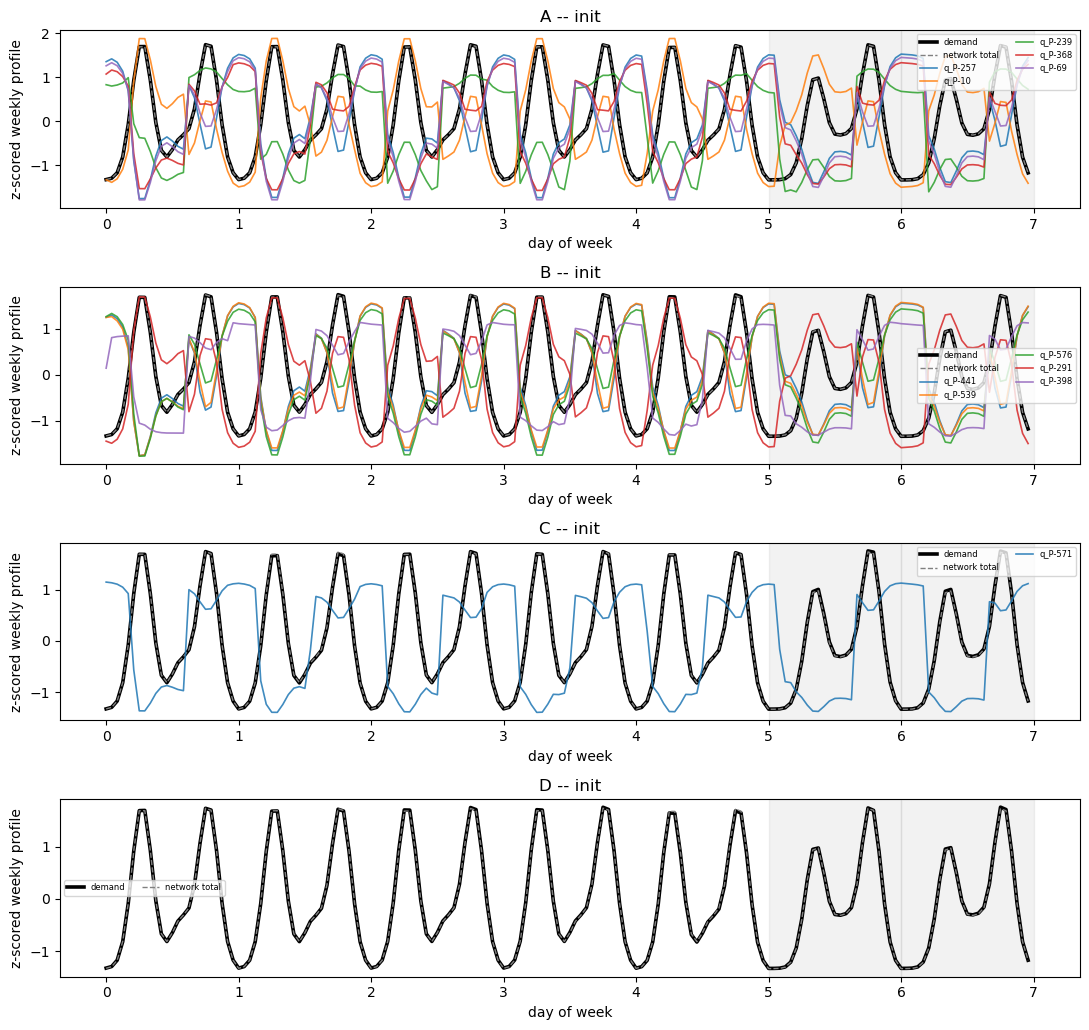

In [18]:
S0 = SEL[SEL["config_id"] == B0.config_id]
KIND = "flow"
fig, axes = plt.subplots(len(R0.names), 1, figsize=(11, 2.6 * len(R0.names)),
                         squeeze=False)
for ax, d in zip(axes[:, 0], R0.names):
    ids = list(S0[(S0["arm"] == "target") & (S0["district"] == d)
                  & (S0["kind"] == KIND)]["id"])
    F.selection_vs_demand(ax, P0, ids, d, phase="init")
plt.tight_layout(); plt.show()

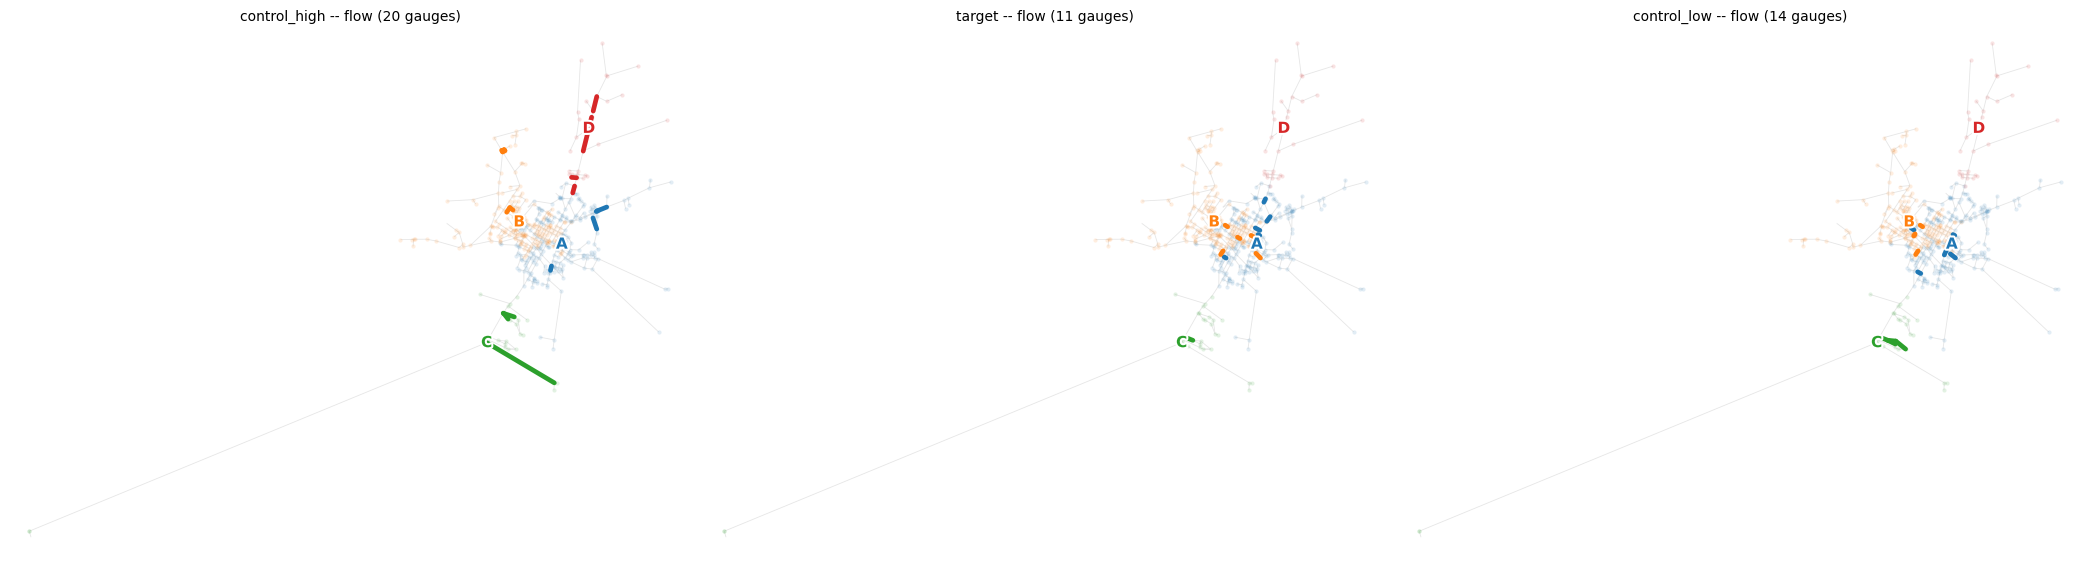

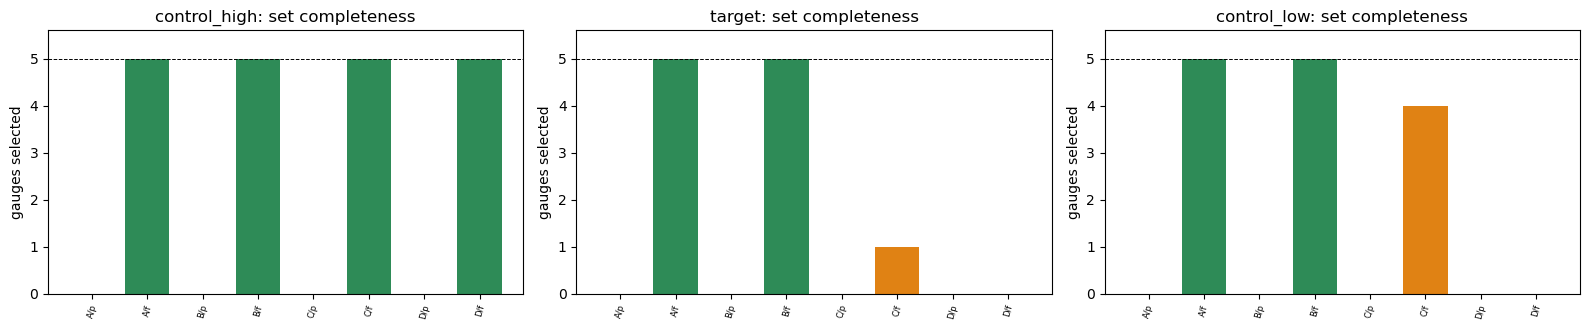

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.6))
for ax, arm in zip(axes, ("control_high", "target", "control_low")):
    F.selection_network(ax, TOPO, S0, R0.districts, arm, KIND)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, arm in zip(axes, ("control_high", "target", "control_low")):
    F.coverage_bars(ax, COV[COV["config_id"] == B0.config_id], arm)
plt.tight_layout(); plt.show()

In [20]:
# The arms, scored on axes they were NOT chosen on. `served_own` is the
# independent topological opinion; `r_res_own_init` is NOT a quality signal
# here (the all-residential initial map leaves nothing for it to resolve).
cols = [c for c in ["w1", "w2", "top2", "snr_home", "served_own", "neg_mass",
                    "r_res_own_init"] if c in SEL.columns]
display(SEL.groupby(["config_id", "arm", "kind"])[cols].mean().round(3))

w1     w2   top2  snr_home  served_own  neg_mass  r_res_own_init
config_id               arm          kind                                                                         
fast_greedy__2ab65bc6   control_high flow      1.000  0.000  1.000    46.102       0.737     0.011           0.391
                        control_low  flow      0.692  0.297  0.989    15.469       0.244     0.194           0.013
                        target       flow      0.628  0.338  0.965    13.896       0.242     0.099           0.011
                        unusable     flow      0.000  0.000  0.000     2.640       0.340     0.544          -0.029
                                     pressure  0.000  0.000  0.000     7.887         NaN     1.020          -0.025
girvan_newman__6f359aad control_high flow      1.000  0.000  1.000    43.716       0.645     0.000           0.403
                        control_low  flow      0.962  0.038  1.000    10.299       0.207     0.272           0.031
                        target       flow      0.634  0.353  0.987     9.602       0.255     0.230           0.026
                        unusable     flow      0.000  0.000  0.000     1.055       0.824     0.000          -0.077
                                     pressure  0.000  0.000  0.000     6.706         NaN     1.031          -0.018
spectral__29fddafe      control_high flow      1.000  0.000  1.000    49.213       0.649     0.001           0.455
                        control_low  flow      0.677  0.319  0.996    11.158       0.297     0.178           0.021
                        target       flow      0.621  0.356  0.977    11.344       0.359     0.176           0.016
                        unusable     flow      0.000  0.000  0.000     1.442       0.736     0.442          -0.074
                                     pressure  0.000  0.000  0.000     5.100         NaN     0.637           0.018

## 8. Read-out

**(a) Does each channel carry a placement?** §2f. A `degenerate` verdict means
every gauge of that channel reports the same blend, so five of them are one of
them. Drop the channel from the FL feature set rather than carrying it.

**(b) Is the dependence real, or is it the threshold?** §2c. If `n_live<=1_%`
is high and the tier counts move across `null_factor`, the mixture is one-hot
by construction. If the purity histogram has mass off both ends that survives
the sweep, §6's target set is a measured object.

**(c) Which partition to carry forward.** The one whose target arm covers every
district, because an FL experiment needs every client on a target sensor at
once. That is a stronger test than the diagonal-to-off-diagonal ratio alone: a
cleanly separated partition with no quantified mixtures gives FL no dependence
to recover, and a heavily mixed one gives it no clean client.

**(d) `R > 1`.** `R` is a ratio to the diagonal, not a fraction. An off-diagonal
mean above 1 says a district's meters respond more to someone else's drift than
to their own — printed beside 0.05 it reads like a fraction and gets skimmed
past, so `configs.csv` counts them explicitly.

**(e) What is NOT claimed.** One beta, so no linearity check: these numbers hold
at this operating point. Influence, not causality. `r_res_own_init` is not a
quality signal — the all-residential initial map leaves every district the same
regime token at t0, so init-phase resemblance has nothing to resolve (mean
`r_res_own` 0.117 at init against 0.486 at final on D-Town flow). And the honest
sample size is the number of partitions, not the number of gauges.

**(f) Anti-phase mass.** `placement.rebuild_mixture(gains, kind,
mode="magnitude")` is a diagnostic, not a shipped path. The simplex drops
negative gains while `dependence()` averages `|E|`, so the two currently
disagree about sign on the 65.7% of KY7 flow gauges that carry anti-phase mass.
Reconstruction suggests folding magnitude in roughly doubles KY7's mid-band
population and leaves D-Town unchanged. Prove it with `channel_diversity` before
trusting it: if the extra gauges are all the same reading, it recovered nothing.

### Next
`handoff.json` per configuration names `districts.yml`, one yml per arm, and
any degenerate channels. Run the arms as matched conditions: if FL recovers
dependence on `target` and not on `control_high`, the recovery is the mixture
and not the pipeline.